# Network Analysis
## Lab 1
### Introduction to Networks with igraph

In this lab, we will work through standard ideas on importing and handling networks using computational tools. I will use the `Python` software, along with mainly the `igraph` package for now in order to maintain a consistent language (please note many other good network-oriented packages exist, such as [`networkx`](https://networkx.org/en/) or [`statnet`](https://github.com/statnet/statnet) for Social Network Analysis.)

In the first lab, we will focus on:
- creating networks from scratch,
- understanding nodes and edges,
- visualizing graphs,
- working with adjacency matrices,
- and alternating between representations,

Additionally, we will explore a few real-world graphs to give you experience in handling network data. Before we begin, you will need to open any Jupyter notebook terminal. Steps:
1. Open a Python / Command Window terminal.
2. Install required packages: `pip install jupyterlab notebook igraph numpy matplotlib pycairo`.
3. Open this notebook. One way is by going to the folder where it is saved, opening a Command Window terminal, and type: `jupyter notebook`.
4. Follow along with the interactive code.

In [1]:
# Load installed packages
import igraph as ig
import numpy as np
import matplotlib.pyplot as plt

## 1. A simple simulated network

We start by creating a small network by hand.
This helps us understand how to handle and represent networks before loading real data.

IGRAPH UN-- 6 6 --
+ attr: name (v)
+ edges (vertex names):
A--B, B--C, C--D, A--D, A--E, C--F


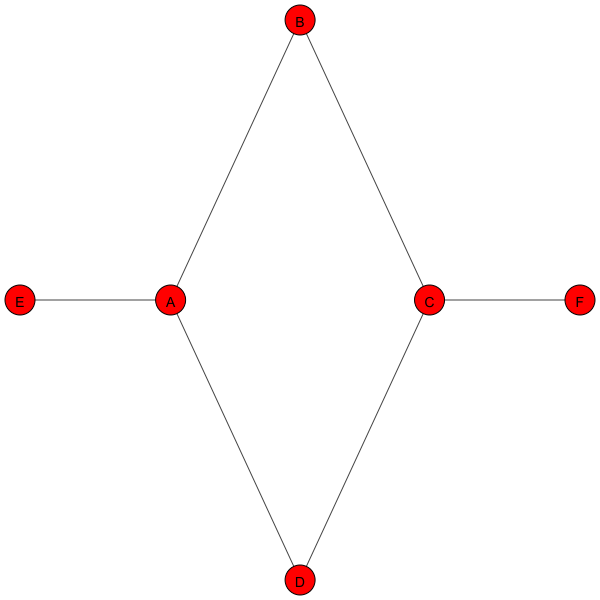

In [7]:
# Create an undirected graph with 6 nodes
g = ig.Graph(n=6, edges=[
    (0,1), (1,2), (2,3), (3,0),  # cycle
    (0,4), (2,5)                # branches
])

# Name the nodes
g.vs["name"] = ["A", "B", "C", "D", "E", "F"]
print(g) # Display graph structure

# Visualize the graph
ig.plot(
    g,
    layout="fr",
    vertex_label=g.vs["name"],
    vertex_size=30
)

## Manipulating graphs

We now learn how to:
- add and remove nodes,
- add and remove edges,
- modify edge weights.

['A', 'B', 'C', 'D', 'E', 'F', 'G']


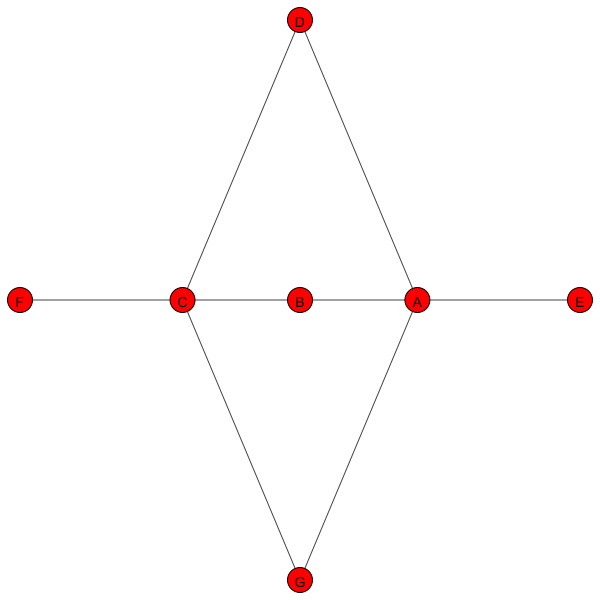

In [8]:
# Add a new node
g.add_vertex(name="G")

# Check updated node list
print(g.vs["name"])

# Add an edge between existing nodes (by index)
g.add_edge(0, 6)   # A -> G (if directed)

# Or by name
g.add_edge("C", "G")

ig.plot(
    g,
    layout="fr",
    vertex_label=g.vs["name"],
    vertex_size=25
)

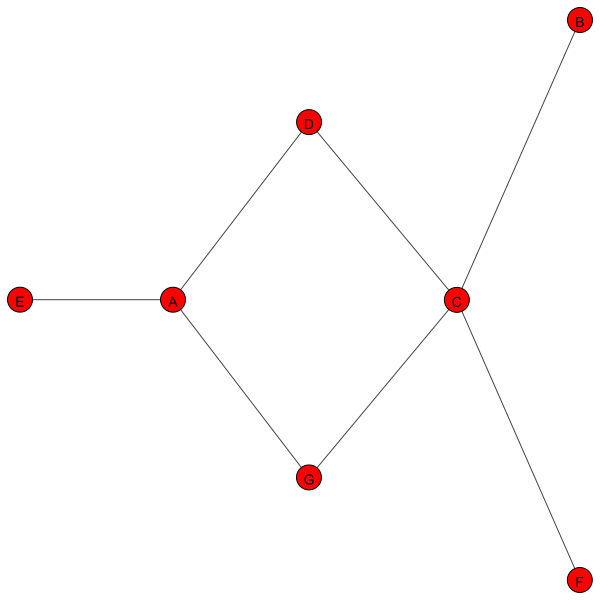

In [9]:
# Remove an edge (by endpoints)
g.delete_edges([("A", "B")])

ig.plot(
    g,
    layout="fr",
    vertex_label=g.vs["name"],
    vertex_size=25
)

In [10]:
# Assign weights if not present
g.es["weight"] = [1.0] * g.ecount()

# Modify a specific edge weight
edge_id = g.get_eid("C", "G")
g.es[edge_id]["weight"] = 2.5
print(g)

# Inspect edge list with weights
print(list(zip(g.get_edgelist(), g.es["weight"])))

IGRAPH UNW- 7 7 --
+ attr: name (v), weight (e)
+ edges (vertex names):
B--C, C--D, A--D, A--E, C--F, A--G, C--G
[((1, 2), 1.0), ((2, 3), 1.0), ((0, 3), 1.0), ((0, 4), 1.0), ((2, 5), 1.0), ((0, 6), 1.0), ((2, 6), 2.5)]


## 2. Directed and weighted networks

Many economic networks are:
- directed (supplier → buyer),
- weighted (strength of interaction).

IGRAPH DNW- 6 6 --
+ attr: name (v), weight (e)
+ edges (vertex names):
A->B, B->C, C->D, D->A, A->E, C->F


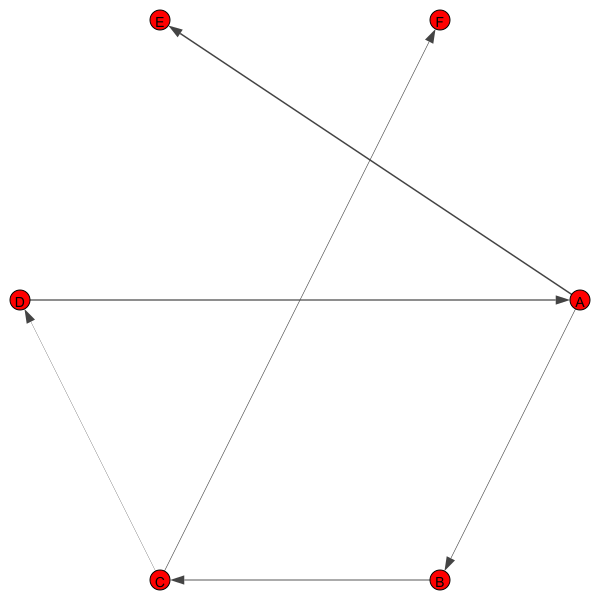

In [11]:
# Weighted graph examples
g_dir = ig.Graph(
    edges=[(0,1), (1,2), (2,3), (3,0), (0,4), (2,5)],
    directed=True
)

g_dir.vs["name"] = ["A", "B", "C", "D", "E", "F"]
g_dir.es["weight"] = [0.2, 0.3, 0.1, 0.4, 0.5, 0.2]
print(g_dir)

ig.plot(
    g_dir,
    layout="circle",
    vertex_label=g_dir.vs["name"],
    edge_width=[3*w for w in g_dir.es["weight"]],
    arrow_size=0.7
)


## 3. Adjacency matrix representation

Every network with $n$ nodes can be represented as an $n \times n$ matrix matrix $\mathbf{A}$. Easily accomplished transformation via code.

[[0.  0.2 0.  0.  0.5 0. ]
 [0.  0.  0.3 0.  0.  0. ]
 [0.  0.  0.  0.1 0.  0.2]
 [0.4 0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0. ]]


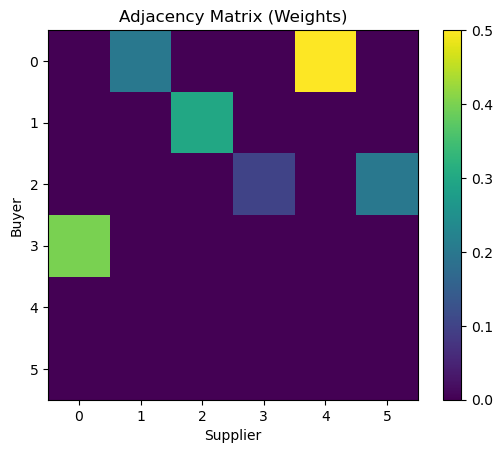

In [12]:
# Extract adjacency matrix with weights
A = np.array(g_dir.get_adjacency(attribute="weight").data)
print(A)

# Visualize adjacency matrix as heatmap
plt.imshow(A, cmap="viridis")
plt.colorbar()
plt.title("Adjacency Matrix (Weights)")
plt.xlabel("Supplier")
plt.ylabel("Buyer")
plt.show()

## 4. Basic network properties

In [17]:
print("Number of nodes:", g_dir.vcount())
print("Number of edges:", g_dir.ecount())
print("Is directed?", g_dir.is_directed())
print("Density:", g_dir.density())


Number of nodes: 6
Number of edges: 6
Is directed? True
Density: 0.2


## 5. Real-world example: Karate Club Network

This is a social network of friendships in a karate club, as described in "An Information Flow Model for Conflict and Fission in Small Groups" by Wayne W. Zachary (1977). A social network of a karate club was studied for a period of three years from 1970 to 1972, documenting links between pairs of students who interacted outside the club out of the total 34 members.

0.13903743315508021


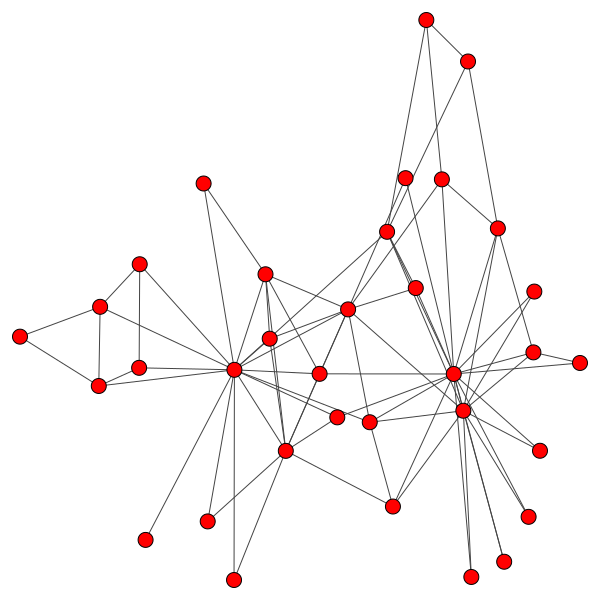

In [14]:
# Extract graph from existing dataset: Karate Club
karate = ig.Graph.Famous("Zachary")
print(karate.density())

# Visualize Karate Club graph
ig.plot(
    karate,
    layout="fr",
    vertex_size=15,
    vertex_label=None
)

## 6. Synthetic trade network example

Nodes represent countries. Edges represent export flows.

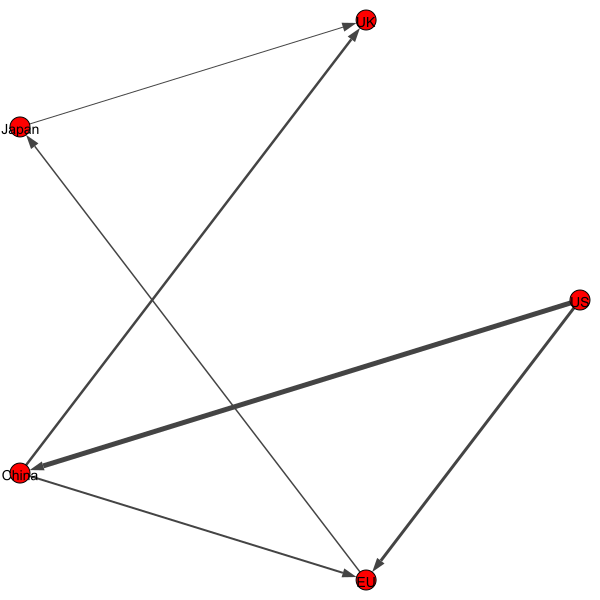

In [13]:
countries = ["US", "EU", "China", "Japan", "UK"]

trade = ig.Graph(
    directed=True,
    edges=[
        (0,1), (0,2), (2,1), (1,3), (3,4), (2,4)
    ]
)

trade.vs["name"] = countries
trade.es["weight"] = [300, 500, 200, 150, 100, 250]

ig.plot(
    trade,
    layout="circle",
    vertex_label=trade.vs["name"],
    edge_width=[w/100 for w in trade.es["weight"]],
    arrow_size=0.8
)


## Graph visualization: why layout matters

When we visualize a network, the position of nodes is usually determined by an *algorithm*. These layouts are not unique and do **not** change the underlying network.

Different layouts emphasize different aspects of the same graph:
- clusters,
- hubs,
- hierarchy,
- symmetry.

### Force-directed layout (Fruchterman–Reingold)

Nodes repel each other, edges act like springs. Often highlights clusters and community structure.

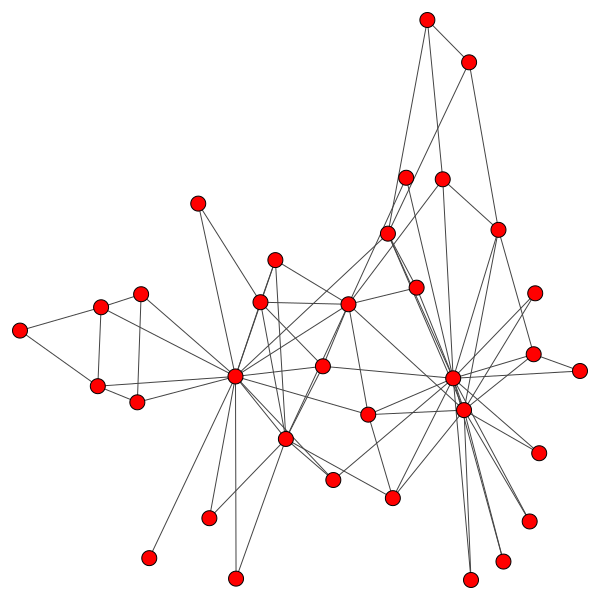

In [15]:
g = karate
ig.plot(
    g,
    layout=g.layout_fruchterman_reingold(),
    vertex_size=15,
    vertex_label=None
)

### Circular layout

Nodes are placed on a circle, ignoring network structure. Useful for comparing degrees or directions.

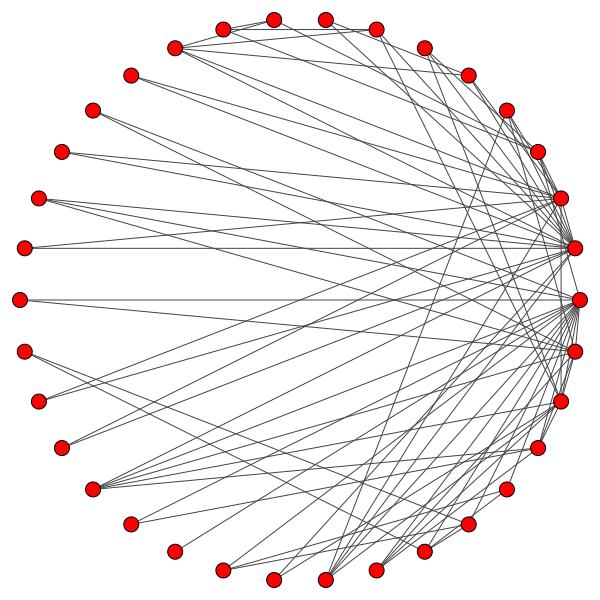

In [16]:
ig.plot(
    g,
    layout=g.layout_circle(),
    vertex_size=15,
    vertex_label=None
)

### Kamada–Kawai layout

Uses shortest-path distances between nodes. Often spreads nodes more evenly than force-directed layouts.

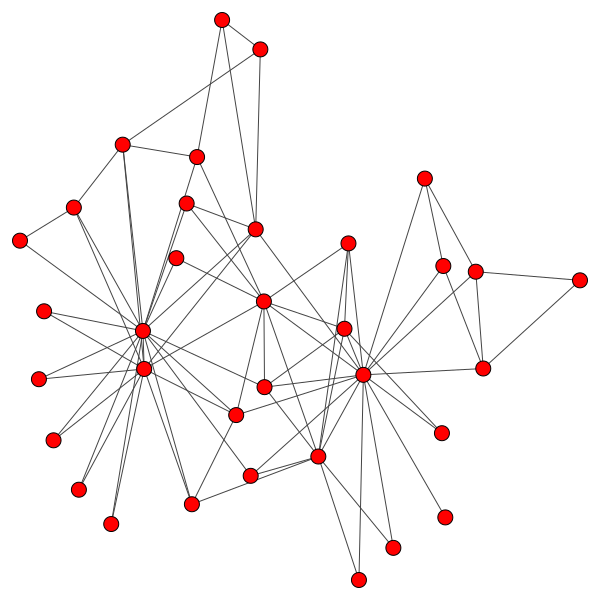

In [17]:
ig.plot(
    g,
    layout=g.layout_kamada_kawai(),
    vertex_size=15,
    vertex_label=None
)

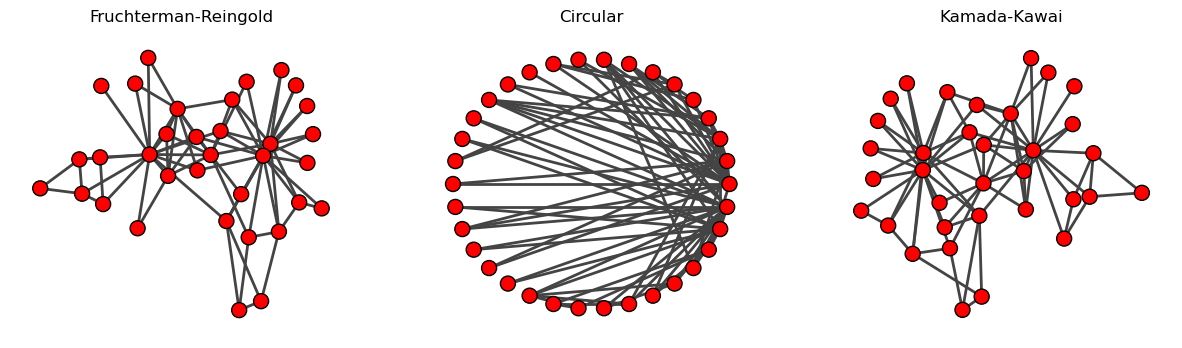

In [18]:
# Side-by-side comparison
layouts = {
    "Fruchterman-Reingold": g.layout_fruchterman_reingold(),
    "Circular": g.layout_circle(),
    "Kamada-Kawai": g.layout_kamada_kawai()
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, layout) in zip(axes, layouts.items()):
    ig.plot(
        g,
        layout=layout,
        target=ax,
        vertex_size=15,
        vertex_label=None
    )
    ax.set_title(name)

plt.show()


## Exercises

1. Add a new node to the simulated network and connect it to at least two existing nodes.
2. Add weights to all edges and visualize them using edge thickness.
3. Remove one edge and discuss how the network structure changes.
4. Try at least two different layouts and explain which one you find most informative.
2. Convert the karate network to directed (arbitrarily). What changes?
3. Extract and visualize the adjacency matrix of the trade network.

In [29]:
# Provide your answers here